# 01 · Integración, limpieza y EDA

Este notebook inventaría e integra los tres CSV de actuaciones de BAwiR y genera un dataset limpio a nivel jugador-partido.

Los archivos de actuaciones reúnen inicialmente 11.475 filas. La limpieza retira 898 registros agregados que no representan actuaciones individuales y conserva 10.577 observaciones. Para ordenar el histórico se define una identidad operativa mediante `player_name_norm + competition`, se construye `match_id` combinando fecha y partido y se convierten los minutos de `MM:SS` a formato decimal. Los originales de `data/raw` permanecen inalterados y la elegibilidad se aplica posteriormente en el notebook 02.

La identidad basada en el nombre no garantiza la resolución de homónimos ni de posibles cambios entre competiciones. Por esta razón, las conclusiones de esta etapa se limitan a describir la calidad, cobertura y distribución de los datos y no se interpretan de forma causal.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")

TABLE_DIR = ROOT / "reports" / "tables" / "01_eda"
FIGURE_DIR = ROOT / "reports" / "figures" / "01_eda"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "acb": "acb_games_1718_acb_games_1718.csv",
    "euroleague": "euroleague_games_1718_euroleague_games_1718.csv",
    "eurocup": "eurocup_games_1718_eurocup_games_1718.csv",
}

frames, manifest = [], []
for competition, filename in FILES.items():
    path = RAW_DIR / filename
    frame = pd.read_csv(path)
    manifest.append({
        "competition": competition,
        "role": "games",
        "file": filename,
        "rows": len(frame),
        "columns": len(frame.columns),
    })
    frame["competition"] = competition
    frames.append(frame)

raw = pd.concat(frames, ignore_index=True)
source_manifest = pd.DataFrame(manifest)
source_manifest.to_csv(TABLE_DIR / "source_manifest.csv", index=False)
display(source_manifest)
assert len(raw) == 11_475, f"Filas raw inesperadas: {len(raw)}"

,competition,role,file,rows,columns
0,acb,games,acb_games_1718_acb_games_1718.csv,3939,38
1,euroleague,games,euroleague_games_1718_euroleague_games_1718.csv,3932,38
2,eurocup,games,eurocup_games_1718_eurocup_games_1718.csv,3604,38


## Limpieza reproducible

Se mantienen las columnas originales y se añaden nuevos campos necesarios para ordenar y analizar los datos. La regla de exclusión elimina `Team == "0"` y los valores `Player == "Equipo"` o `Player == "Team"`, ya que representan totales del equipo y no actuaciones individuales. Se contemplan ambas etiquetas porque los CSV utilizan español e inglés según la competición.

In [2]:
def minutes_to_float(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "0":
        return 0.0
    match = re.fullmatch(r"(\d+):(\d{1,2})", text)
    if not match:
        raise ValueError(f"Formato de minutos no reconocido: {value!r}")
    minutes, seconds = map(int, match.groups())
    if seconds >= 60:
        raise ValueError(f"Segundos fuera de rango: {value!r}")
    return minutes + seconds / 60

def normalize_player(value):
    text = re.sub(r"\s+", " ", str(value).strip().lower())
    return re.sub(r"[^a-z0-9 áéíóúüñ\-.]", "", text)

work = raw.copy()
work["Date"] = pd.to_datetime(work["Date"], dayfirst=True, errors="raise")
work["MP_min"] = work["MP"].map(minutes_to_float)
work["PIR"] = pd.to_numeric(work["PIR"], errors="raise")
work["match_id"] = work["Date"].dt.strftime("%Y-%m-%d") + "||" + work["Game"].astype(str)
work["player_name_norm"] = work["Player"].map(normalize_player)
work["player_id"] = work["player_name_norm"] + "||" + work["competition"]

aggregate_labels = {"equipo", "team"}
valid_player = (
    work["Team"].astype(str).ne("0")
    & ~work["Player"].astype(str).str.strip().str.lower().isin(aggregate_labels)
)
removed = work.loc[~valid_player].copy()
clean = (work.loc[valid_player]
         .sort_values(["competition", "player_id", "Date", "match_id"])
         .reset_index(drop=True))

assert len(removed) == 898, f"Exclusiones inesperadas: {len(removed)}"
assert len(clean) == 10_577, f"Filas limpias inesperadas: {len(clean)}"
assert clean[["competition", "match_id", "Team", "player_id", "Date", "MP_min", "PIR"]].notna().all().all()

## Controles de calidad e identidad

Las tablas se exportan en CSV para poder recrear las visualizaciones en Power BI. Una clave duplicada se conserva para inspección: no se elimina automáticamente sin evidencia de que sea un duplicado real.

In [3]:
key = ["competition", "match_id", "Team", "player_id"]
duplicate_mask = clean.duplicated(key, keep=False)

flow = pd.DataFrame([
    {"stage": "raw", "rows": len(raw)},
    {"stage": "placeholders_removed", "rows": len(removed)},
    {"stage": "clean", "rows": len(clean)},
])
flow_by_competition = (pd.concat([
    raw.groupby("competition").size().rename("raw"),
    removed.groupby("competition").size().rename("removed"),
    clean.groupby("competition").size().rename("clean"),
], axis=1).fillna(0).astype(int).reset_index())
quality = (clean.groupby("competition")
           .agg(rows=("player_id", "size"), players=("player_id", "nunique"), matches=("match_id", "nunique"),
                date_min=("Date", "min"), date_max=("Date", "max"), mp_missing=("MP_min", lambda s: int(s.isna().sum())),
                pir_missing=("PIR", lambda s: int(s.isna().sum())))
           .reset_index())
identity = (clean.groupby(["competition", "player_name_norm"])["Player"]
            .agg(rows="size", written_variants="nunique", variants=lambda s: " | ".join(sorted(set(map(str, s)))))
            .reset_index().sort_values(["written_variants", "rows"], ascending=False))

exports = {
    "rows_flow.csv": flow,
    "rows_flow_by_competition.csv": flow_by_competition,
    "quality_by_competition.csv": quality,
    "placeholders_removed.csv": removed,
    "duplicate_key_summary.csv": pd.DataFrame({"duplicate_rows": [int(duplicate_mask.sum())], "duplicate_groups": [clean.loc[duplicate_mask].groupby(key).ngroups]}),
    "duplicate_rows_detail.csv": clean.loc[duplicate_mask],
    "player_identity_variants.csv": identity,
}
for filename, table in exports.items():
    table.to_csv(TABLE_DIR / filename, index=False)

display(flow, flow_by_competition, quality)

,stage,rows
0,raw,11475
1,placeholders_removed,898
2,clean,10577


,competition,raw,removed,clean
0,acb,3939,306,3633
1,eurocup,3604,288,3316
2,euroleague,3932,304,3628


,competition,rows,players,matches,date_min,date_max,mp_missing,pir_missing
0,acb,3633,272,153,2017-09-29,2018-01-21,0,0
1,eurocup,3316,351,144,2017-10-10,2018-01-17,0,0
2,euroleague,3628,245,152,2017-10-12,2018-01-19,0,0


## Cobertura, esquema y valores ausentes

Antes de interpretar distribuciones se documentan la cobertura temporal, el número de partidos y jugadores y los valores ausentes de cada columna. La tabla de esquema permite conocer qué variables proceden directamente de BAwiR y cuáles se han creado durante la limpieza.

Los ausentes no se imputan en esta etapa. La imputación forma parte del pipeline de cada modelo y se ajustará exclusivamente con sus datos de entrenamiento.

In [4]:
schema = pd.DataFrame({
    "column": clean.columns,
    "dtype": [str(clean[column].dtype) for column in clean.columns],
    "missing_rows": [int(clean[column].isna().sum()) for column in clean.columns],
    "missing_pct": [float(clean[column].isna().mean() * 100) for column in clean.columns],
    "unique_values": [int(clean[column].nunique(dropna=True)) for column in clean.columns],
})
schema["origin"] = np.where(schema["column"].isin(
    ["competition", "MP_min", "match_id", "player_name_norm", "player_id"]
), "derived", "BAwiR")
schema.to_csv(TABLE_DIR / "schema_and_missingness.csv", index=False)

appearances = (clean.groupby(["competition", "player_id"])
               .agg(player_name=("Player", "first"), appearances=("match_id", "size"),
                    first_date=("Date", "min"), last_date=("Date", "max"),
                    mean_minutes=("MP_min", "mean"), mean_pir=("PIR", "mean"))
               .reset_index())
appearances.to_csv(TABLE_DIR / "player_appearance_summary.csv", index=False)
display(schema.sort_values(["missing_pct", "column"], ascending=[False, True]).head(15))

,column,dtype,missing_rows,missing_pct,unique_values,origin
17,AST,int64,0,0.0,16,BAwiR
22,BLKag,int64,0,0.0,6,BAwiR
21,BLKfv,int64,0,0.0,7,BAwiR
37,CombinID,object,0,0.0,850,BAwiR
20,Counteratt,int64,0,0.0,6,BAwiR
15,DRB,int64,0,0.0,13,BAwiR
31,Date,datetime64[ns],0,0.0,89,BAwiR
30,Day,object,0,0.0,36,BAwiR
23,Dunks,int64,0,0.0,7,BAwiR
11,FT,int64,0,0.0,15,BAwiR


## EDA univariante: minutos y PIR

Los minutos aproximan el tiempo de exposición de cada jugador y PIR resume su producción estadística total. Se presentan distribuciones por competición para detectar asimetrías, colas y diferencias de escala. La comparación es descriptiva y no implica que la competición cause esas diferencias.

Cada figura dispone de su tabla fuente. Esto permite reproducirla en Python o trasladarla a Power BI sin recalcular el pipeline.

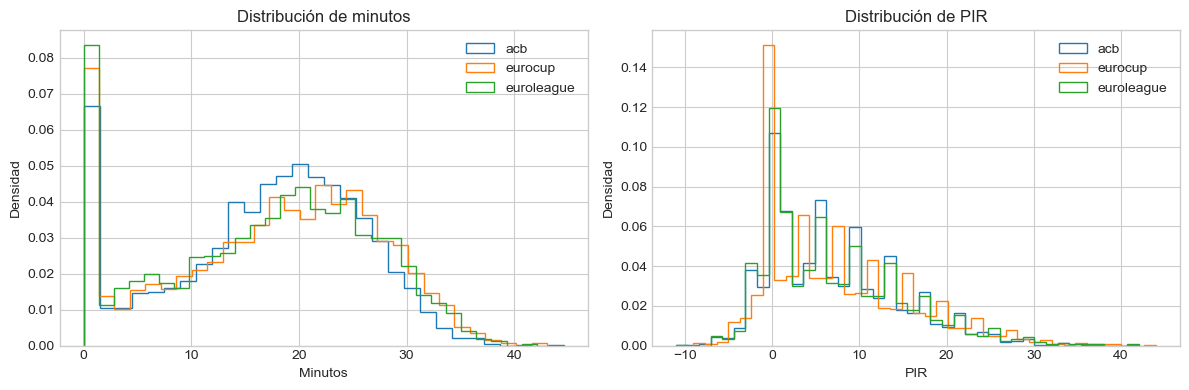

,competition,MP_min_count,MP_min_mean,MP_min_std,MP_min_median,MP_min_min,MP_min_max,PIR_count,PIR_mean,PIR_std,PIR_median,PIR_min,PIR_max,PTS_count,PTS_mean,PTS_std,PTS_median,PTS_min,PTS_max,TRB_count,TRB_mean,TRB_std,TRB_median,TRB_min,TRB_max,AST_count,AST_mean,AST_std,AST_median,AST_min,AST_max
0,acb,3633,16.983214,8.907015,18.266667,0.0,44.583333,3633,7.020919,7.521123,6.0,-11,42,3633,6.830168,5.851038,6.0,0,35,3633,2.690063,2.517068,2.0,0,16,3633,1.332783,1.736549,1.0,0,12
1,eurocup,3316,17.475930,9.868437,18.791667,0.0,43.066667,3316,7.429735,8.292260,6.0,-9,44,3316,7.073884,6.339298,6.0,0,42,3316,2.634198,2.537162,2.0,0,18,3316,1.526236,1.946240,1.0,0,13
2,euroleague,3628,16.855017,9.874204,18.250000,0.0,42.100000,3628,7.118247,7.993143,6.0,-11,42,3628,6.654631,6.115113,6.0,0,33,3628,2.548236,2.513408,2.0,0,17,3628,1.462789,1.927839,1.0,0,15


In [5]:
eda_distribution = clean[["competition", "player_id", "Date", "MP_min", "PIR"]].copy()
eda_distribution.to_csv(TABLE_DIR / "eda_minutes_pir_source.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for competition, values in clean.groupby("competition")["MP_min"]:
    axes[0].hist(values, bins=30, density=True, histtype="step", label=competition)
axes[0].legend()
axes[0].set(title="Distribución de minutos", xlabel="Minutos", ylabel="Densidad")
for competition, values in clean.groupby("competition")["PIR"]:
    axes[1].hist(values, bins=40, density=True, histtype="step", label=competition)
axes[1].legend()
axes[1].set(title="Distribución de PIR", xlabel="PIR", ylabel="Densidad")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "minutes_pir_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

descriptive = (clean.groupby("competition")[["MP_min", "PIR", "PTS", "TRB", "AST"]]
               .agg(["count", "mean", "std", "median", "min", "max"]))
descriptive.columns = [f"{variable}_{statistic}" for variable, statistic in descriptive.columns]
descriptive = descriptive.reset_index()
descriptive.to_csv(TABLE_DIR / "descriptive_statistics_by_competition.csv", index=False)
display(descriptive)

## EDA bivariante: minutos y producción

Se examina la relación entre minutos y PIR porque el objetivo representa producción total por partido y, por tanto, está condicionado por las oportunidades de juego. El color representa el número de observaciones por hexágono en escala logarítmica: así se distinguen tanto las concentraciones principales como las zonas menos frecuentes. El gráfico no debe interpretarse como un efecto causal de jugar más minutos: rol, calidad, rival y contexto pueden influir simultáneamente.

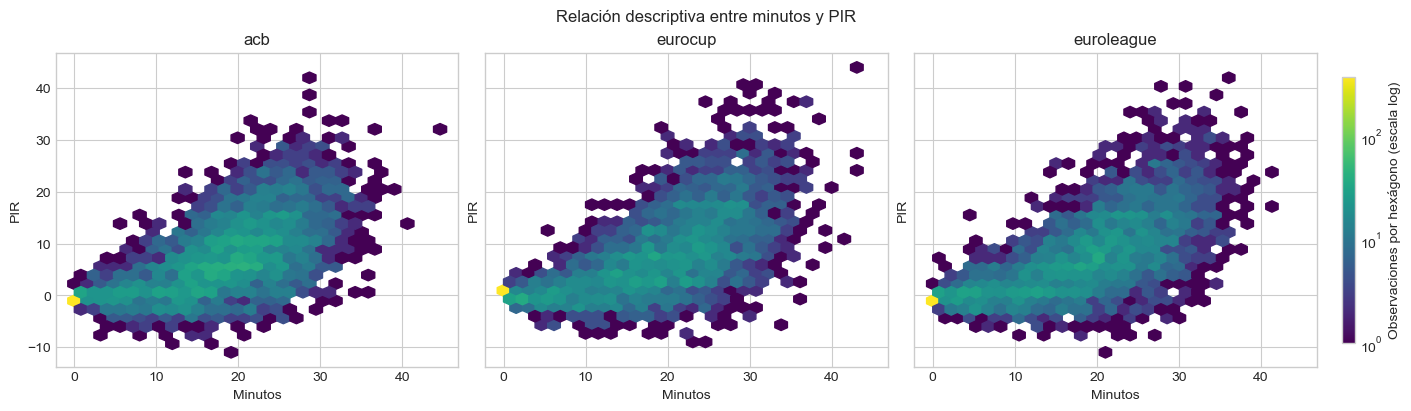

,competition,rows,pearson_mp_pir,spearman_mp_pir
0,acb,3633.0,0.623720,0.655520
1,eurocup,3316.0,0.663527,0.704911
2,euroleague,3628.0,0.677740,0.711687


In [6]:
minutes_pir = clean[["competition", "MP_min", "PIR"]].dropna().copy()
correlations = (minutes_pir.groupby("competition")
                .apply(lambda frame: pd.Series({
                    "rows": len(frame),
                    "pearson_mp_pir": frame["MP_min"].corr(frame["PIR"], method="pearson"),
                    "spearman_mp_pir": frame["MP_min"].corr(frame["PIR"], method="spearman"),
                }), include_groups=False).reset_index())
minutes_pir.to_csv(TABLE_DIR / "figure_minutes_vs_pir_source.csv", index=False)
correlations.to_csv(TABLE_DIR / "minutes_pir_correlations.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True, layout="constrained")
for ax, (competition, frame) in zip(axes, minutes_pir.groupby("competition", sort=True)):
    image = ax.hexbin(frame["MP_min"], frame["PIR"], gridsize=28, mincnt=1, cmap="viridis", bins="log")
    ax.set(title=competition, xlabel="Minutos", ylabel="PIR")
fig.colorbar(image, ax=axes.ravel().tolist(), label="Observaciones por hexágono (escala log)", shrink=0.85, pad=0.02)
fig.suptitle("Relación descriptiva entre minutos y PIR")
fig.savefig(FIGURE_DIR / "minutes_vs_pir.png", dpi=160, bbox_inches="tight")
plt.show()
display(correlations)

## EDA de participación

El número de apariciones disponibles por jugador anticipa qué parte de la población podrá cumplir una regla de historial mínimo. La elegibilidad concreta no se decide aquí: se calculará en el notebook 02 sobre partidos objetivo y únicamente con información anterior.

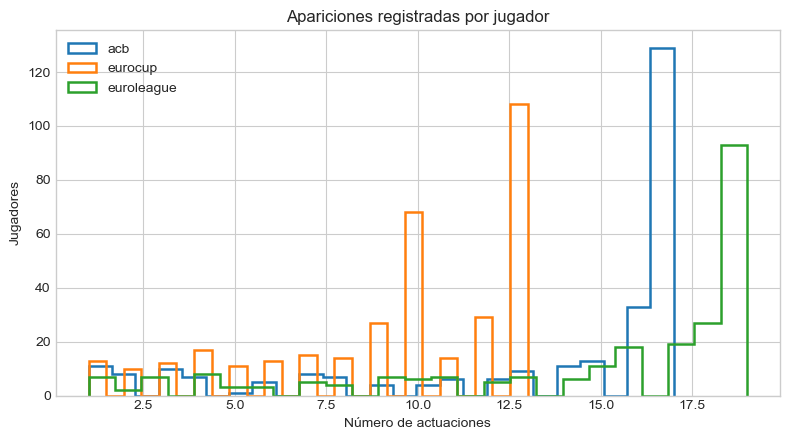

Dataset limpio: 10,577 filas · 868 jugadores


In [7]:
appearance_source = appearances[["competition", "player_id", "appearances"]].copy()
appearance_source.to_csv(TABLE_DIR / "figure_player_appearances_source.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
for competition, frame in appearance_source.groupby("competition"):
    ax.hist(frame["appearances"], bins=25, histtype="step", linewidth=1.8, label=competition)
ax.set(title="Apariciones registradas por jugador", xlabel="Número de actuaciones", ylabel="Jugadores")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "player_appearances.png", dpi=160, bbox_inches="tight")
plt.show()

clean.to_csv(PROCESSED_DIR / "player_game_clean_1718.csv", index=False, date_format="%Y-%m-%d")
print(f"Dataset limpio: {len(clean):,} filas · {clean['player_id'].nunique():,} jugadores")

## Resultado y trazabilidad

La ejecución confirma que el dataset limpio contiene 10.577 actuaciones y que los controles fallarían de forma explícita si cambiasen los originales o las reglas de limpieza. Las variantes ortográficas ayudan a localizar posibles problemas de identidad, pero no bastan para decidir si dos registros representan a la misma persona. Del mismo modo, la relación observada entre minutos y PIR se interpreta como una asociación descriptiva y no como causalidad.